# Copilot

In [10]:
from datetime import datetime

from bs4 import BeautifulSoup
import pandas as pd
import re
import numpy as np
from datetime import timedelta
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Correct data

In [12]:
df1 = pd.read_csv(f'data/autoscout/{datetime.now().strftime("%y.%m.%d")}_autoscout_raw.csv')
# df1 = pd.read_csv(f'data/autoscout/24.04.04_autoscout_raw.csv')
df1['title'] = df1['brand'] + ' ' + df1['title']
df1 = df1.drop(['brand', 'rating'], axis=1)
df1['location'] = df1['location'].str.extract(r'ES-\d+\s(.*)', expand=False)
df1['year'] = df1['year'].str.split('/').str[1].astype(int)

df2 = pd.read_csv(f'data/flexicar/{datetime.now().strftime("%y.%m.%d")}_flexicar_raw.csv')
# df2 = pd.read_csv(f'data/flexicar/24.04.04_flexicar_raw.csv')
df2['location'] = df2['city']
df2['cv'] = df2['description'].str.extract(r'\((\d+)CV\)', expand=False)
df2['cv'] = df2['cv'].replace(np.nan, '0')
df2['cv'] = df2['cv'].astype(int)
df2['cv'] = df2['cv'].replace(0, np.nan)
df2 = df2.drop(['discounted_price', 'monthly_rate', 'iva_deducible', 'offer', 'city'], axis=1)

df3 = pd.read_csv(f'data/ocasion/{datetime.now().strftime("%y.%m.%d")}_ocasion_raw.csv')
# df3 = pd.read_csv(f'data/ocasion/24.04.04_ocasion_raw.csv')
df3 = df3.loc[df3['status'] == 'Available']
df3['city'] = df3['city'].fillna('')
df3['district'] = df3['district'].fillna('')
df3['location'] = df3['city'] + ' ' + df3['district']
df3['location'] = df3['location'].replace(' ', np.nan)
df3 = df3.drop(['discounted_price', 'discount', 'status', 'city', 'district', 'libro', 'warranty', 'owner', 'vista'], axis=1)

In [13]:
df2 = df2[df1.columns]
df3 = df3[df1.columns]
df = pd.concat([df1,df2,df3], ignore_index=True)
df['location'] = df['location'].str.lower().str.strip()
df = df.drop_duplicates()
df = df.dropna(subset=['full_price'])
df['age'] = 2024 - df['year']
df = df.drop(['year'], axis=1)

df = df[df['full_price'] <= 15000]
# df.drop_duplicates(subset=['title', 'description', 'full_price', 'mileage', 'transmission', 'fuel', 'cv', 'age'], inplace=True)


# Normalize and score

In [14]:
scaler = MinMaxScaler()
df_norm = df.copy()
df_norm['full_price'] = scaler.fit_transform(df_norm[['full_price']])
df_norm['age'] = scaler.fit_transform(df_norm[['age']])
df_norm['mileage'] = scaler.fit_transform(df_norm[['mileage']])
df_norm['cv'] = scaler.fit_transform(df_norm[['cv']])
df_norm['cv'] = df_norm['cv'].replace(np.nan, 0)

# Correct valence
df_norm['full_price'] = (df_norm['full_price'] - 1)* -1
df_norm['age'] = (df_norm['age'] - 1)* -1
df_norm['mileage'] = (df_norm['mileage'] - 1)* -1

df['rating'] = (df_norm.full_price * 2) + df_norm.cv + df_norm.mileage + df_norm.age
df['rating_no_cv'] = (df_norm.full_price * 2) + df_norm.mileage + df_norm.age
# df_norm.sort_values(by='rating', ascending=False)

df['description'] = df.title + ' ' + df.description
df['title'] = df['title'].apply(lambda x: x.split(" ")[0])

df.to_csv(f'data/{datetime.now().strftime("%y.%m.%d")}_assembled.csv', index=False)

In [9]:
df.sort_values(by='rating', ascending=False).head(50)

,title,description,full_price,mileage,transmission,fuel,cv,location,url,age,rating,rating_no_cv
3239,Ford,Ford Fiesta 1.0 EcoBoost 70kW (95CV) Active S/...,1490.0,51559,Manual,Gasolina,95.0,alcalá de henares,https://www.flexicar.es//coches-ocasion/ford-f...,3,3.599108,3.376886
277,Peugeot,Peugeot Peugeot 308 1.6 BlueHDi Style 120,9999.0,735,Manual,Diésel,120.0,bigastro,https://www.autoscout24.es//anuncios/peugeot-3...,6,2.795896,2.295896
747,Nissan,Nissan Nissan Leaf 40 kWh Acenta,12490.0,25966,Automático,Eléctrico,150.0,malaga,https://www.autoscout24.es//anuncios/nissan-le...,5,2.617398,1.784065
746,Opel,Opel Opel Astra 1.2T S/S Business Elegance 145,12490.0,51300,Manual,Gasolina,145.0,las rozas,https://www.autoscout24.es//anuncios/opel-astr...,3,2.528849,1.751071
4021,Ford,Ford Fiesta 1.0 EcoBoost 103kW(140CV) ST-Line ...,13990.0,17850,Manual,Gasolina,140.0,villarreal,https://www.flexicar.es//coches-ocasion/ford-f...,4,2.477102,1.754879
2933,Citroen,Citroen C3 Aircross PureTech 81kW (110CV) S&S ...,12990.0,14652,Manual,Gasolina,110.0,alcorcón 2,https://www.flexicar.es//coches-ocasion/citroe...,3,2.435135,2.046246
2037,Fiat,Fiat Tipo 1.0 73kW (100CV),11490.0,27000,Manual,Gasolina,100.0,roquetas,https://www.flexicar.es//coches-ocasion/fiat-t...,3,2.421687,2.143909
1249,Peugeot,Peugeot Peugeot 308 SW 1.2 PureTech S&S Style 130,12903.0,18677,Manual,Gasolina,131.0,paterna,https://www.autoscout24.es//anuncios/peugeot-3...,5,2.418577,1.796355
2125,Fiat,Fiat Tipo Sedan Life 1.0 73kW (100CV),11980.0,20639,Manual,Gasolina,100.0,cáceres,https://www.flexicar.es//coches-ocasion/fiat-t...,3,2.413229,2.135451
2124,Fiat,Fiat Tipo Sedan Life 1.0 73kW (100CV),11980.0,23427,Manual,Gasolina,100.0,cáceres,https://www.flexicar.es//coches-ocasion/fiat-t...,3,2.385143,2.107365


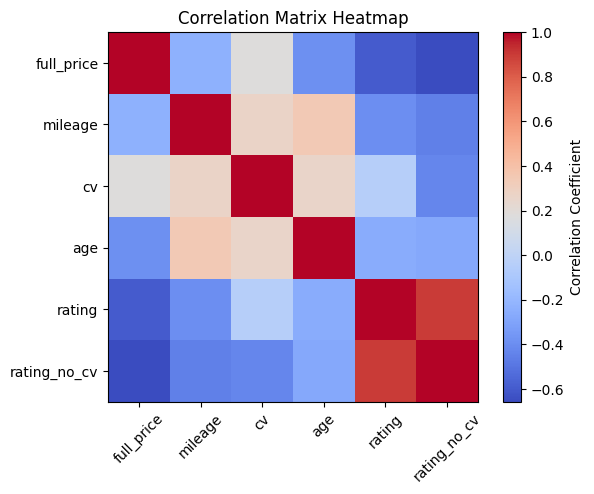

In [12]:
spearman_matrix = df.drop(['title', 'url', 'description', 'transmission', 'fuel', 'location'], axis=1).corr(method='spearman')
correlation_matrix = df.drop(['title', 'url', 'description', 'transmission', 'fuel', 'location'], axis=1).corr()

plt.imshow(correlation_matrix, cmap='coolwarm')  # Adjust 'coolwarm' for preferred colormap

# Add labels and title
plt.colorbar(label='Correlation Coefficient')
plt.xticks(range(len(spearman_matrix.columns)), spearman_matrix.columns, rotation=45)
plt.yticks(range(len(spearman_matrix.columns)), spearman_matrix.columns)
plt.title('Correlation Matrix Heatmap')

# Display the plot
plt.show()